In [7]:
import numpy as np
import matplotlib.pyplot as plt

In [8]:
class Interval_finder:
    def __init__(self,array):
        self.array = array
        self.m_max = len(array) - 1
        self.m = self.m_max
    
    def find_m(self,val):
        f = True
        while f:
            f = not ((self.array[self.m-1] <= val))
            if f: self.m-=1
        return self.m         

In [ ]:
class Inversor:
    
    
    def __init__(self,function,tau_grid,t_grid):
        
        self.function = function
        
        self.tau_grid = tau_grid
        self.delta = self.tau_grid[1] - self.tau_grid[0]
        
        self.t_grid = t_grid
        self.t_grid_size = len(self.t_grid)
    
        self.finder = Interval_finder(function)


        self.inverse = np.zeros((self.t_grid_size))      
        

    
    def one_point(self,t,tau_left,fun_left,fun_right):

        f = tau_left + self.delta/(fun_right-fun_left) * (t - fun_left)
        
        return f

    
    def inv(self):
        
        for s in reversed(range(self.t_grid_size)):
            m = self.finder.find_m(self.t_grid[s])
            self.inverse[s] = self.one_point(self.t_grid[s],self.tau_grid[m-1],self.function[m-1],self.function[m])
        
        return self.inverse        
    





In [10]:
class Compositor:
    def __init__(self,left_function,right_function,tau_grid):
        self.left_function = left_function
        self.right_function = right_function
        
        self.tau_grid = tau_grid
        self.delta = tau_grid[1] - tau_grid[0]

        self.n_t_grid = len(right_function)

        self.finder = Interval_finder(tau_grid)

        self.composition = np.zeros((self.n_t_grid))

    def one_point(self,tau_left,left_fun_left,left_fun_right,right_fun):
        a_t = (left_fun_right-left_fun_left)/(self.delta)*(right_fun-tau_left)+left_fun_left
        return a_t 
    
    def compose(self):
        for s in reversed(range(self.n_t_grid)):
            m = self.finder.find_m(self.right_function[s])
            self.composition[s] = self.one_point(self.tau_grid[m-1],self.left_function[m-1],self.left_function[m],self.right_function[s])

        return self.composition    



In [11]:
g = np.load("g.npy")
alpha = np.load("alpha.npy")
tau_grid = np.load("tau_grid.npy") 

FileNotFoundError: [Errno 2] No such file or directory: 'g.npy'

In [12]:
plt.figure() 
plt.plot(tau_grid,np.exp(g-1/2 * g**2))
plt.plot(tau_grid,g)
plt.xlabel(r'$\tau$',fontsize=17)
plt.ylabel(r'$\alpha$',fontsize=17,rotation=0)    
plt.show()

NameError: name 'tau_grid' is not defined

<Figure size 640x480 with 0 Axes>

In [7]:
T_max = max(g)
t_grid = np.arange(0,T_max+0.01,0.01)
g_inversor = Inversor(g,tau_grid,t_grid)
g_inv =  g_inversor.inv()

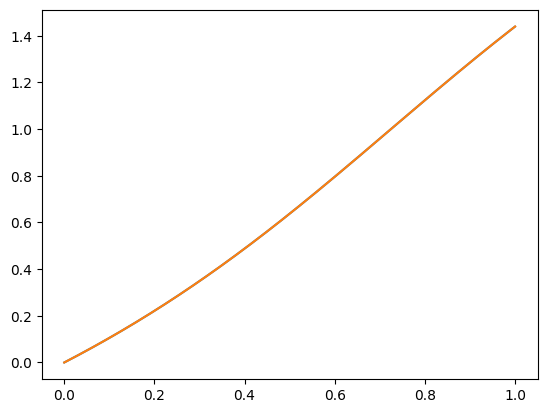

In [8]:
plt.figure()
plt.plot(tau_grid,g)
plt.plot(g_inv,t_grid)
plt.show()

In [9]:
a_composition = Compositor(alpha,g_inv,tau_grid)
a = a_composition.compose()

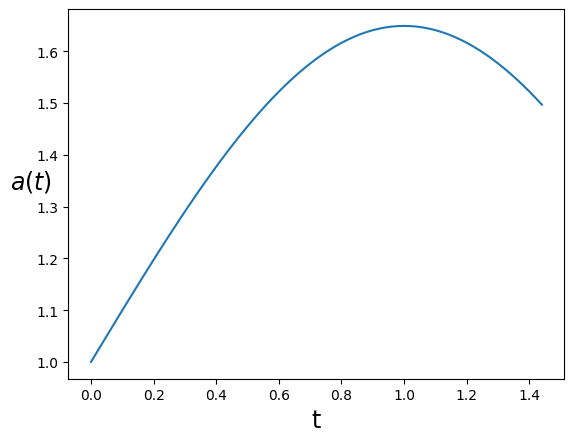

In [12]:
plt.figure()
plt.plot(t_grid,a)
plt.xlabel("t",fontsize=17)
plt.ylabel(r"$a(t)$",fontsize=17,rotation=0)
plt.show()

In [ ]:
"""
x = np.linspace(0,1,100)
y = np.zeros((100))
y = x**2 

t_grid = np.linspace(0,max(y),100)

test = Inversor(y,x,t_grid)
test.inv()
z = test.inverse
"""


In [ ]:
"""
plt.figure()
plt.plot(x,y)
plt.plot(x,z)
"""

NameError: name 'x' is not defined

<Figure size 640x480 with 0 Axes>

In [ ]:
"""
t_grid = np.linspace(0,2,100)
tau_grid = np.linspace(0,4,100)
f_1 = t_grid ** 2
f_2 = tau_grid ** 2
comp_test = Compositor(f_2,f_1,tau_grid)
comp_test.compose()
f_3 = comp_test.composition
"""

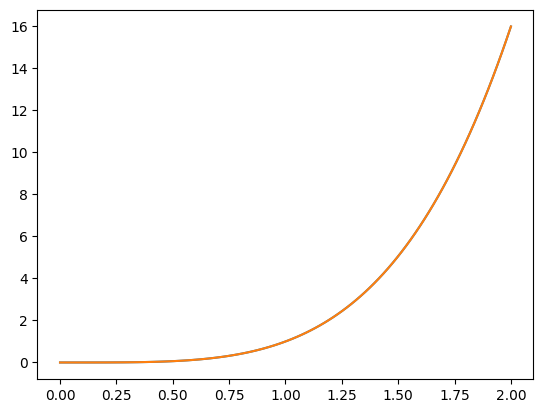

In [ ]:
"""
plt.figure()
plt.plot(t_grid,f_3)
plt.plot(t_grid,t_grid ** 4)
"""